#Loading Dataset

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
 96% 1.02G/1.06G [00:07<00:00, 136MB/s]
100% 1.06G/1.06G [00:07<00:00, 153MB/s]


In [3]:
from zipfile import ZipFile
with ZipFile('/content/dogs-vs-cats.zip', 'r') as zip:
  zip.extractall()
  print('Done!')

Done!


#Importing Libraries

In [27]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [29]:
# Normalization
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)


In [31]:
base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

/tmp/ipython-input-570338007.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [33]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)


In [35]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 67ms/step - accuracy: 0.9450 - loss: 0.1584 - val_accuracy: 0.9812 - val_loss: 0.0531
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 56ms/step - accuracy: 0.9859 - loss: 0.0391 - val_accuracy: 0.9812 - val_loss: 0.0531
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.9887 - loss: 0.0333 - val_accuracy: 0.9820 - val_loss: 0.0485
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.9905 - loss: 0.0284 - val_accuracy: 0.9828 - val_loss: 0.0477
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9902 - loss: 0.0274 - val_accuracy: 0.9826 - val_loss: 0.0494
Restoring model weights from the end of the best epoch: 4.


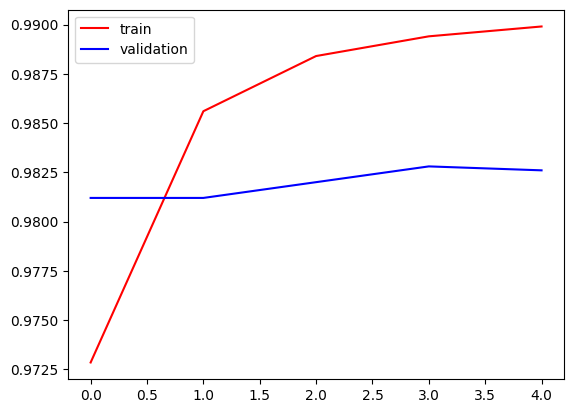

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

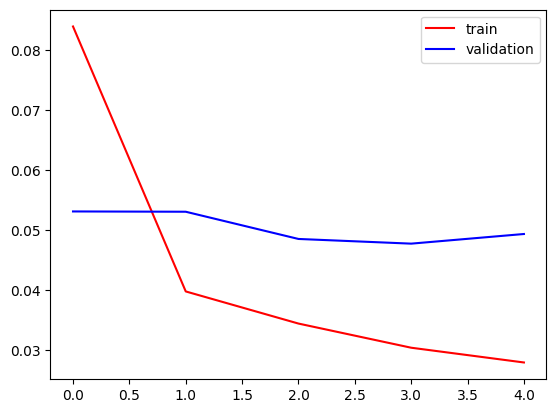

In [37]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

Accuracy = 98.2%

In [38]:
test_loss, test_acc = model.evaluate(test_ds)
print('Test accuracy:', test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9844 - loss: 0.0427
Test accuracy: 0.9828000068664551


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


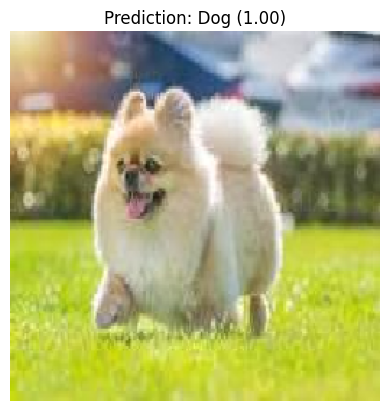

In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


def predict_image(img_path):
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # normalize
    img_array = np.expand_dims(img_array, axis=0)  # batch dimension

    prediction = model.predict(img_array)[0][0]
    label = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img)
    plt.title(f"Prediction: {label} ({prediction:.2f})")
    plt.axis('off')
    plt.show()

# Example usage
predict_image('/content/download.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


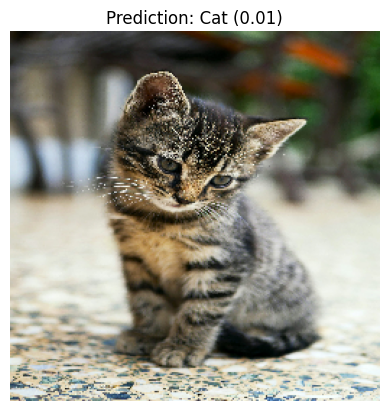

In [47]:
predict_image("/content/photo-1529778873920-4da4926a72c2.jpg")

In [48]:
model.save('model.h5')

In [49]:
from google.colab import files
files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>